# Thesis: Reclaimed Timber in Deep Generative Design
**Notebook ID:** c23_design_space_optimizer     
**Author:** Jasper Cluistra   
**Last Updated:** 2026-03-19
### Design space optimization script
**Goal:** Optimize the structure by iterating over structural performance, circular performance, and total cost.
**Inputs:**
*   Search space definition
*   Trained surrogate model
*   Material input dataset

**Outputs:**
*   Optimized design candidates
*   Ranked solution set

# SETUP

In [1]:
# Run once per notebook session before the GA loop.
# Loads all dependencies, stock data, search space, and GA configuration.
#
# Produces the following session variables:
#   optimizer_search_space        — dict[str, (float, float)]
#   df_input_stock                — pd.DataFrame
#   GA_CONFIG                     — pipeline-level settings dict
#   FIXED_NORMALIZATION_CONSTANTS — initial normalisation bounds
#   MODEL_PREFIX                  — surrogate model artifact stem
#
# ES algorithm parameters (mu, lam, n_generations, sigma_init etc.) are
# defined in ESConfig in c30_ga_runner.py — not here. GA_CONFIG carries
# pipeline-level settings only (weights, MILP, penalty, structural schedule).

import importlib
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd

import config
from workflows import c22_stage_geometry             as stage_geometry
from workflows import c24_stage_feasibility          as stage_feas       # stage_feas throughout
from workflows import c25_stage_cost_matrix          as stage_cost
from workflows import c26_stage_MILP                 as stage_milp
from workflows import c27_stage_GNN                  as stage_gnn
from workflows import c28_stage_fitness_score        as stage_fitness
from workflows import c28_stage_normalization_bounds as stage_bounds

# Hot-reload all workflow modules so notebook edits are picked up immediately
for _mod in [stage_geometry, stage_feas, stage_cost,
             stage_milp, stage_gnn, stage_fitness, stage_bounds]:
    importlib.reload(_mod)

# =============================================================================
# REPRODUCIBILITY
# =============================================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# =============================================================================
# FLAGS
# =============================================================================

TESTING = False   # True → loads small stock CSV for fast development runs

# =============================================================================
# SEARCH SPACE
# =============================================================================

json_path = config.DATA_IO_PATH / "search_space.json"
if not json_path.exists():
    raise FileNotFoundError(
        f"search_space.json not found at {json_path}. "
        "Generate it from the geometry stage before running the GA."
    )
with open(json_path, "r", encoding="utf-8") as f:
    optimizer_search_space = json.load(f)

print(f"Search space loaded: {len(optimizer_search_space)} variables")

# =============================================================================
# STOCK DATA
# =============================================================================

stock_file = (
    config.TIMBER_STOCK_PATH / "complete_timber_small.csv"
    if TESTING
    else config.TIMBER_STOCK_PATH / "complete_timber_v2.csv"
)
if not stock_file.exists():
    raise FileNotFoundError(f"Stock CSV not found: {stock_file}")

# Try common delimiter/encoding combinations — handles GH exports with ; sep
_df_input_stock = None
for _opts in [
    {"sep": ",",  "encoding": "utf-8"},
    {"sep": ";",  "encoding": "utf-8"},
    {"sep": ",",  "encoding": "latin1"},
    {"sep": ";",  "encoding": "latin1"},
]:
    try:
        _df = pd.read_csv(stock_file, **_opts)
        if _df.shape[1] > 1:
            _df_input_stock = _df
            print(f"Stock loaded: {len(_df)} elements  "
                  f"(sep='{_opts['sep']}', encoding='{_opts['encoding']}')")
            break
    except Exception:
        pass

if _df_input_stock is None:
    raise ValueError(
        f"Could not parse stock CSV at {stock_file}. "
        "Tried , and ; delimiters with utf-8 and latin1 encoding."
    )

df_input_stock = _df_input_stock
df_input_stock.columns = df_input_stock.columns.str.strip()

# =============================================================================
# SURROGATE MODEL PREFIX
# =============================================================================

MODEL_PREFIX = "ID20260512_193129_LR3e-04_EP150_BS32_FA0.50_ROC0.894"

# =============================================================================
# GA CONFIGURATION
#
# Pipeline-level settings only — weights, MILP, penalty, bounds.
# ES algorithm parameters live in ESConfig in c30_ga_runner.py.
# =============================================================================

GA_CONFIG = {
    # Fitness weights — omega_1: cost, omega_2: reuse rate, omega_3: waste
    # omega_4 (structural penalty) is scheduled dynamically — see w_structural_*
    "fitness_weights": {
        "omega_1": 1.0,
        "omega_2": 1.0,
        "omega_3": 1.0,
    },

    # MILP — how many times a new-stock element may be assigned across slots
    "new_stock_max_uses": 100,

    # Penalty fitness assigned to infeasible or failed pipeline evaluations
    "penalty_fitness": 1e6,

    # One-time normalisation bounds computed once at GA startup
    "use_one_time_bounds":   True,
    "bounds_probe_attempts": 8,

    # Structural penalty curriculum — omega_4 ramps linearly over generations
    # Early generations tolerate structural infeasibility; later ones penalise it
    "w_structural_start": 0.2,
    "w_structural_end":   0.8,
}

# =============================================================================
# INITIAL NORMALISATION CONSTANTS
# Overwritten by the one-time bounds solve in c30_ga_evaluator.py
# =============================================================================

# Placeholder — overwritten by one-time bounds solve in c30_ga_evaluator.py
# Do not use this value directly; always run the evaluator cell first.
FIXED_NORMALIZATION_CONSTANTS = stage_fitness.get_default_normalization_constants()

# =============================================================================
# SUMMARY
# =============================================================================

print(f"\n{'='*55}")
print("GA SESSION READY")
print(f"{'='*55}")
print(f"  Search space variables:  {len(optimizer_search_space)}")
print(f"  Stock elements:          {len(df_input_stock)}")
print(f"  Model prefix:            {MODEL_PREFIX}")
print(f"  Fitness weights:         "
      f"ω1={GA_CONFIG['fitness_weights']['omega_1']}  "
      f"ω2={GA_CONFIG['fitness_weights']['omega_2']}  "
      f"ω3={GA_CONFIG['fitness_weights']['omega_3']}")
print(f"  Structural schedule:     "
      f"ω4 {GA_CONFIG['w_structural_start']} → {GA_CONFIG['w_structural_end']}")
print(f"  New stock max uses:      {GA_CONFIG['new_stock_max_uses']}")
print(f"  Fixed normalization:     {FIXED_NORMALIZATION_CONSTANTS}")
print(f"  Penalty fitness:         {GA_CONFIG['penalty_fitness']:.0e}")
print(f"  TESTING mode:            {TESTING}")
print(f"{'='*55}\n")

display(df_input_stock.head(3))

Config System loaded successfully, Code running locally from thesis_generative_timber and Data is connected to OneDrive 2.2 - 2.4.

GRID: 5x3, EDGE_LENGTH: 3.0, LAYER_HEIGHT: 1.5, DIVISIONS: 8, NUM_SAMPLES: 20000

IMPACT_FACTOR_A1_A3: 0.25, IMPACT_FACTOR_RECOVERED_C1: 0.0085, "ENERGY_PREP_SAW_A5: 0.02, ENERGY_OFFCUT_FACTOR_C3_C4: 0.276, SCARCITY_PENALTY: 0

parameters loaded from c:\Users\jaspe\Documents\PyRepo\thesis_generative_timber\c00_headquarter_params.py
Search space loaded: 73 variables
Stock loaded: 526 elements  (sep=';', encoding='utf-8')

GA SESSION READY
  Search space variables:  73
  Stock elements:          526
  Model prefix:            ID20260512_193129_LR3e-04_EP150_BS32_FA0.50_ROC0.894
  Fitness weights:         ω1=1.0  ω2=1.0  ω3=1.0
  Structural schedule:     ω4 0.2 → 0.8
  New stock max uses:      100
  Fixed normalization:     {'C_max': 8.0, 'R_max': 100.0, 'W_max': 0.4}
  Penalty fitness:         1e+06
  TESTING mode:            False



,Member_ID,State,Length,Depth,Width,Length_Category,Availability_Probability,f_mk,f_tk,E_modulus_eff,E_modulus_005,f_vk,f_c0k,k_density,mean_density,Origin_Country,Transport_Dist,EmissionFactor,Donor_Role,Cut_Loss_mm
0,NS_00000,0,1800.0,100.0,38.0,primary,1.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,Netherlands,49.35,0.1764,NaN,NaN
1,NS_00001,0,1800.0,100.0,50.0,primary,1.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,Germany,310.79,0.1768,NaN,NaN
2,NS_00002,0,1800.0,100.0,63.0,primary,1.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,Germany,289.49,0.1794,NaN,NaN


# EVALUATION

## 24_ Geometry

In [2]:
# =============================================================================
# c30_ga_geometry_check.py — One-time Geometry Sanity Check
# =============================================================================
#
# Optional: run once before the GA to verify the geometry stage produces
# the expected topology (39 nodes, 120 members) and that the output columns
# match what downstream stages expect.
#
# Set RUN_GEOMETRY_CHECK = True to execute; False to skip silently.
# Keep False during production GA runs — this adds ~5-30s unnecessarily.

RUN_GEOMETRY_CHECK = True

EXPECTED_NODES   = 39
EXPECTED_MEMBERS = 120

if RUN_GEOMETRY_CHECK:
    geometry_out = stage_geometry.run_random_geometry_stage(
        optimizer_search_space=optimizer_search_space,
        sample_id=0,
    )

    df_vertices_example         = geometry_out["df_vertices"]
    df_edges_example            = geometry_out["df_edges"]
    df_geometry_overview_example = geometry_out["df_geometry_overview"]

    n_nodes   = len(df_vertices_example)
    n_members = len(df_edges_example)

    print(f"Geometry check: {n_nodes} nodes, {n_members} members")

    if n_nodes != EXPECTED_NODES:
        print(f"  WARNING: expected {EXPECTED_NODES} nodes, got {n_nodes}")
    else:
        print(f"  Nodes:   {n_nodes} / {EXPECTED_NODES} ✓")

    if n_members != EXPECTED_MEMBERS:
        print(f"  WARNING: expected {EXPECTED_MEMBERS} members, got {n_members}")
    else:
        print(f"  Members: {n_members} / {EXPECTED_MEMBERS} ✓")

    display(df_geometry_overview_example[["edge_id", "V1", "V2", "length_m"]].head(5))

else:
    print("Geometry check skipped (RUN_GEOMETRY_CHECK = False).")

Geometry check: 39 nodes, 120 members
  Nodes:   39 / 39 ✓
  Members: 120 / 120 ✓


,edge_id,V1,V2,length_m
0,e0,0,1,3.750
1,e1,0,6,2.625
2,e2,1,2,1.125
3,e3,1,7,2.704
4,e4,2,3,3.000


## 24-27 Iteration

In [4]:
# =============================================================================
# ONE-TIME BOUNDS SOLVE + SMOKE TEST
# =============================================================================
import config 
import c23_ga_evaluator as ga_eval

FIXED_NORMALIZATION_CONSTANTS, BOUNDS_SOURCE_INFO = (
    ga_eval._compute_one_time_normalization_constants(
        search_space = optimizer_search_space,
        df_stock     = df_input_stock,
        config_dict  = GA_CONFIG,
    )
)
print(f"\nNormalisation constants: {FIXED_NORMALIZATION_CONSTANTS}")
print(f"Source: {BOUNDS_SOURCE_INFO}")

print("\nRunning evaluator smoke test...")
_test_design = stage_geometry.sample_random_design(optimizer_search_space)
_test_eval   = ga_eval.evaluate_design_candidate(
    design_params        = _test_design,
    df_stock             = df_input_stock,
    fixed_norm_constants = FIXED_NORMALIZATION_CONSTANTS,
    config_dict          = GA_CONFIG,
    model_prefix         = MODEL_PREFIX,
    generation           = 0,
    max_generations      = 1,
    sample_id            = 99_999,
    verbose              = True,
)
print(f"Smoke test status: {_test_eval['status']}")
if _test_eval["reason"] is not None:
    print(f"Reason: {_test_eval['reason']}")
print("Evaluator ready.")

Cost matrix filter: 120 slots × 526 stock = 63,120 combinations
  Load: 270.0 kN total  (2.00 kN/m² × 135 m²)
  Stage 1 (length):    43,442 eliminated  (19,678 remaining, 31.2%)
  Force estimation:    max tension=37.2 kN  max compression=-31.7 kN  mean |F|=6.8 kN
  Stage 3 (EC5):        1,891 eliminated  (17,787 remaining, 28.2%)
    3a slenderness      -   11  (19,667 remaining)
    3b depth/length     -  136  (19,531 remaining)
    3c width/depth      -1,386  (18,145 remaining)
    3d/e strength       -  358  (17,787 remaining)
  [bounds probe 1] success → {'C_max': 672.6184840976649, 'R_max': 75.83333333333333, 'W_max': 40.014019290951346}

Normalisation constants: {'C_max': 672.6184840976649, 'R_max': 75.83333333333333, 'W_max': 40.014019290951346}
Source: {'source': 'one-time-bounds', 'status': 'Optimal', 'attempt': 1}

Running evaluator smoke test...
    ✓ geometry    | 39 nodes, 120 edges
Cost matrix filter: 120 slots × 526 stock = 63,120 combinations
  Load: 270.0 kN total  (2.

[IO] Inference config loaded from ID20260512_193129_LR3e-04_EP150_BS32_FA0.50_ROC0.894_inference_config.json
[IO] Checkpoint loaded — epoch 113  val_loss=0.040550
[TrussEdgeSafetyGNN] Topology cached: 120 edges
[IO] Model ready on cpu  |  edge_index: (2, 120)  |  unidirectional


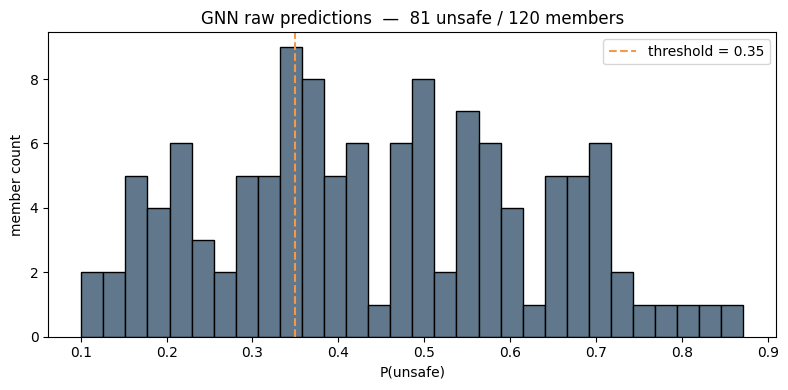

min=0.101  max=0.872  mean=0.444  median=0.416
below 0.1:  0
0.1 – 0.35: 39
0.35 – 0.6: 57
above 0.6:  24


In [8]:
import matplotlib.pyplot as plt
import numpy as np
import config
from c21_surrogate_io import load_surrogate_bundle
import c23_ga_evaluator as ga_eval

# Re-run GNN on the smoke test assignment to access raw predictions
_bundle    = load_surrogate_bundle(prefix_sm=MODEL_PREFIX)
_stock_gnn = stage_gnn.prepare_stock_for_gnn(df_input_stock)

# Rebuild node positions and boundary conditions from smoke test geometry
_, _node_pos, _sup, _load = ga_eval._derive_node_roles(_test_eval["df_vertices"])

# Rebuild milp_assignment integer array from df_results
_stock_idx = {str(mid): i for i, mid in enumerate(df_input_stock["Member_ID"].astype(str))}
_slot_idx  = {str(eid): i for i, eid in enumerate(_test_eval["df_edges"]["edge_id"].astype(str))}
_milp_arr  = np.zeros(120, dtype=int)
for _, row in _test_eval["df_results"].iterrows():
    s = _slot_idx.get(str(row["edge_id"]), -1)
    k = _stock_idx.get(str(row["assigned_timber"]), -1)
    if s >= 0 and k >= 0:
        _milp_arr[s] = k

# Forward pass — get raw predictions
_gnn_out = stage_gnn.run_gnn_stage(
    node_positions  = _node_pos,
    milp_assignment = _milp_arr,
    df_input_stock  = df_input_stock,
    model_bundle    = _bundle,
    stock_df        = _stock_gnn,
    support_nodes   = _sup,
    load_nodes      = _load,
    print_summary   = False,
)
preds = _gnn_out["preds_physical"]

# Plot distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(preds, bins=30, edgecolor="black", color= config.PLOT_COLORS["primary"])
ax.axvline(0.35, color=config.PLOT_COLORS["accent"], lw=1.5, linestyle="--", label="threshold = 0.35")
ax.set_xlabel("P(unsafe)")
ax.set_ylabel("member count")
ax.set_title(f"GNN raw predictions  —  {(preds >= 0.35).sum()} unsafe / 120 members")
ax.legend()
plt.tight_layout()
plt.show()

print(f"min={preds.min():.3f}  max={preds.max():.3f}  "
      f"mean={preds.mean():.3f}  median={np.median(preds):.3f}")
print(f"below 0.1:  {(preds < 0.1).sum()}")
print(f"0.1 – 0.35: {((preds >= 0.1) & (preds < 0.35)).sum()}")
print(f"0.35 – 0.6: {((preds >= 0.35) & (preds < 0.6)).sum()}")
print(f"above 0.6:  {(preds >= 0.6).sum()}")


# GA RUN

In [ ]:
import config
import c23_ga_algorithm as ga_algo
import c23_ga_evaluator as ga_eval
from c21_surrogate_io import load_surrogate_bundle

SURROGATE_BUNDLE = load_surrogate_bundle(prefix_sm=MODEL_PREFIX)
print(f"Bundle pre-loaded: {MODEL_PREFIX}")

evaluate_fn = ga_algo.make_evaluate_fn(
    evaluate_fn_raw      = ga_eval.evaluate_design_candidate,
    df_stock             = df_input_stock,
    fixed_norm_constants = FIXED_NORMALIZATION_CONSTANTS,
    config_dict          = GA_CONFIG,
    bundle               = SURROGATE_BUNDLE,
)

# ---- timing wrapper ----
import time
_base_fn = evaluate_fn
def evaluate_fn(params):
    t0 = time.time()
    fitness, res = _base_fn(params)
    elapsed = time.time() - t0
    status = res.get("status", "?") if res else "?"
    print(f"    eval: {elapsed:.1f}s  status={status}  fitness={fitness:.4f}")
    return fitness, res
# ------------------------


def _ss_to_bounds(ss):
    """Convert JSON search space entries to (lo, hi) tuples for EvolutionStrategy."""
    out = {}
    for k, v in ss.items():
        if v["type"] == "discrete":
            out[k] = (float(min(v["options"])), float(max(v["options"])))
        else:
            out[k] = (float(v["min"]), float(v["max"]))
    return out

es_search_space = _ss_to_bounds(optimizer_search_space)

es = ga_algo.EvolutionStrategy(
    search_space = es_search_space,
    evaluate_fn  = evaluate_fn,
    config       = ga_algo.ESConfig(
        mu              = 15,
        lam             = 30,
        n_generations   = 100,
        sigma_init      = 0.15,
        tournament_size = 3,
        stagnation_limit = 20,
        n_restarts_max   = 3,
        log_every        = 5,
    ),
    seed = 42,
)

result = es.run()

# ANALYSIS

In [ ]:
# =============================================================================
# c30_ga_analysis.py — GA Run Results Analysis
# =============================================================================
#
# Run after es.run() completes. Visualises and summarises the full GA output.
#
# Requires from GA runner (notebook namespace):
#   result          — dict returned by es.run()
#   GA_CONFIG       — pipeline config dict
#   FIXED_NORMALIZATION_CONSTANTS
#
# Produces:
#   fig_convergence     — fitness convergence + sigma evolution
#   fig_population      — final population scatter (cost vs reuse vs waste)
#   fig_best_design     — breakdown of best individual's fitness components
#   fig_feasibility     — GNN feasibility score distribution across evaluations
#   summary             — printed text summary
#
# All figures use config.PLOT_COLORS / PLOT_STYLE palette.

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

import config
from config import PLOT_COLORS as C, PLOT_STYLE as S

# =============================================================================
# GUARD
# =============================================================================

required = ["result", "GA_CONFIG", "FIXED_NORMALIZATION_CONSTANTS"]
missing  = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(
        "Missing variables from GA runner: " + ", ".join(missing) +
        ". Run the GA runner cell first."
    )

history    = result["history"]
best       = result["best_individual"]
best_eval  = result["best_eval_result"] or {}
n_evals    = result["n_evals"]
n_gens     = result["n_generations"]
n_restarts = result["n_restarts"]

# =============================================================================
# GLOBAL STYLE
# =============================================================================

plt.rcParams.update({
    "figure.dpi":        S["dpi"],
    "axes.grid":         True,
    "grid.alpha":        S["grid_alpha"],
    "grid.color":        C["neutral"],
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.edgecolor":    C["black"],
    "axes.labelcolor":   C["black"],
    "xtick.color":       C["black"],
    "ytick.color":       C["black"],
    "text.color":        C["black"],
    "font.size":         10,
    "axes.titlesize":    11,
    "axes.titleweight":  "bold",
    "lines.linewidth":   S["line_width"],
    "lines.markersize":  S["marker_size"],
})

# =============================================================================
# FIG 1a — FITNESS CONVERGENCE
# =============================================================================

gens       = [h["generation"]    for h in history]
best_fit   = [h["best_fitness"]  for h in history]
mean_fit   = [h["mean_fitness"]  for h in history]
worst_fit  = [h["worst_fitness"] for h in history]
best_ever  = [h["best_ever"]     for h in history]
mean_sigma = [h["mean_sigma"]    for h in history]
stagnation = [h["stagnation"]    for h in history]

fig_conv_fitness, ax = plt.subplots(figsize=S["figsize_medium"])
fig_conv_fitness.suptitle("Figure 1a — Fitness Convergence", fontweight="bold", fontsize=13)

ax.fill_between(gens, best_fit, worst_fit, alpha=0.15, color=C["primary"],
                label="Population range")
ax.plot(gens, best_ever, color=C["primary"],   lw=S["line_width"],
        label="Best ever")
ax.plot(gens, mean_fit,  color=C["secondary"], lw=S["line_width"],
        linestyle="--", label="Generation mean")
ax.plot(gens, best_fit,  color=C["accent"],    lw=1.2,
        linestyle=":",  label="Generation best")

_restart_labeled = False
for h in history:
    if h["stagnation"] == 0 and h["generation"] > 1:
        ax.axvline(h["generation"], color=C["danger"], lw=1.0,
                   linestyle="--", alpha=0.6,
                   label="Restart" if not _restart_labeled else "_nolegend_")
        _restart_labeled = True

ax.set_xlabel("Generation")
ax.set_ylabel("Fitness (lower = better)")
ax.set_title("Fitness over generations")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print("fig_conv_fitness ready")

# =============================================================================
# FIG 1b — SELF-ADAPTIVE STEP SIZE
# =============================================================================

fig_conv_sigma, ax = plt.subplots(figsize=S["figsize_small"])
fig_conv_sigma.suptitle("Figure 1b — Self-Adaptive Step Size", fontweight="bold", fontsize=13)

ax.plot(gens, mean_sigma, color=C["primary"], lw=S["line_width"])
ax.set_xlabel("Generation")
ax.set_ylabel("Mean σ")
ax.set_title("Population mean step size — spikes mark restarts")
ax.set_yscale("log")
plt.tight_layout()
plt.show()
print("fig_conv_sigma ready")

# =============================================================================
# FIG 1c — STAGNATION
# =============================================================================

fig_conv_stagnation, ax = plt.subplots(figsize=S["figsize_small"])
fig_conv_stagnation.suptitle("Figure 1c — Stagnation per Generation", fontweight="bold", fontsize=13)

ax.bar(gens, stagnation, color=C["secondary"], width=0.8, edgecolor="none")
ax.axhline(GA_CONFIG.get("patience", 40), color=C["danger"], lw=1.5,
           linestyle="--", label=f"Early stop patience = {GA_CONFIG.get('patience', 40)}")
ax.set_xlabel("Generation")
ax.set_ylabel("Stagnation counter")
ax.set_title("Resets to 0 on improvement or restart")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print("fig_conv_stagnation ready")


# =============================================================================
# FIG 2 — POPULATION SCATTER (cost vs reuse vs waste)
# Collect per-evaluation outcomes from history eval_results
# =============================================================================

# Extract per-evaluation data from history if eval_results were stored
# Falls back to best individual only if history doesn't carry eval details
eval_costs   = []
eval_reuse   = []
eval_waste   = []
eval_fitness = []
eval_gnn     = []

for h in history:
    # ES stores best individual per generation — extract if available
    pass  # history entries don't carry full eval dicts — use best only

# Always show best individual prominently
best_cost    = float(best_eval.get("total_cost",  0))
best_reuse   = float(best_eval.get("reuse_rate",  0))
best_waste   = float(best_eval.get("waste_total", 0))
best_gnn     = float(best_eval.get("gnn_feasibility", 1.0) or 1.0)
best_fitness = float(best.fitness)

fig_best_design, axes = plt.subplots(1, 2, figsize=S["figsize_medium"])
fig_best_design.suptitle("Figure 2 — Best Design Breakdown", fontweight="bold", fontsize=13)

# Fitness component bar chart
fr = best_eval.get("fitness_result") or {}
component_labels = ["Cost\n(ω1)", "Reuse\n(ω2)", "Waste\n(ω3)", "Structural\n(ω4)"]
component_values = [
    float(fr.get("cost_component",        0)),
    float(fr.get("reuse_component",       0)),
    float(fr.get("waste_component",       0)),
    float(fr.get("structural_component",  0)),
]
colors_bar = [C["primary"], C["accent"], C["secondary"], C["danger"]]

ax = axes[0]
bars = ax.bar(component_labels, component_values, color=colors_bar,
              edgecolor=C["black"], linewidth=0.5)
for bar, val in zip(bars, component_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Weighted component value")
ax.set_title(f"Fitness Components  (total = {best_fitness:.4f})")
ax.set_ylim(0, max(component_values) * 1.2 if max(component_values) > 0 else 1)

# Key metrics summary as text
ax = axes[1]
ax.axis("off")

norm = FIXED_NORMALIZATION_CONSTANTS
metrics_text = [
    ("Best fitness",         f"{best_fitness:.4f}"),
    ("Total cost",           f"{best_cost:.2f}"),
    ("Reuse rate",           f"{best_reuse:.1f}%"),
    ("Waste total",          f"{best_waste:.4f}"),
    ("GNN feasibility",      f"{best_gnn:.1f}%"),
    ("",                     ""),
    ("Generations run",      str(n_gens)),
    ("Total evaluations",    str(n_evals)),
    ("Restarts",             str(n_restarts)),
    ("",                     ""),
    ("C_max (norm)",         f"{norm.get('C_max', '?')}"),
    ("R_max (norm)",         f"{norm.get('R_max', '?')}"),
    ("W_max (norm)",         f"{norm.get('W_max', '?')}"),
]

y = 0.95
for label, value in metrics_text:
    if label == "":
        y -= 0.04
        continue
    ax.text(0.05, y, label + ":", fontsize=10, color=C["black"],
            transform=ax.transAxes, va="top")
    ax.text(0.60, y, value, fontsize=10, color=C["primary"],
            transform=ax.transAxes, va="top", fontweight="bold")
    y -= 0.07

ax.set_title("Best Design Metrics")

plt.tight_layout()
plt.show()
print(f"fig_best_design ready")

# =============================================================================
# FIG 3 — DESIGN PARAMETERS of best individual
# =============================================================================

param_names  = list(best.params.keys())
param_values = list(best.params.values())
sigma_values = list(best.sigma)

# Normalise params to [0,1] within their search space bounds for readability
try:
    bounds_lo = np.array([optimizer_search_space[k][0] for k in param_names])
    bounds_hi = np.array([optimizer_search_space[k][1] for k in param_names])
    param_range  = bounds_hi - bounds_lo
    param_norm   = (np.array(param_values) - bounds_lo) / np.where(param_range > 0, param_range, 1)
except Exception:
    param_norm = np.array(param_values)

n_params = len(param_names)

fig_params, axes = plt.subplots(2, 1, figsize=(S["figsize_large"][0], 8))
fig_params.suptitle("Figure 3 — Best Design Parameters", fontweight="bold", fontsize=13)

ax = axes[0]
x_pos = np.arange(n_params)
ax.bar(x_pos, param_norm, color=C["primary"], edgecolor="none", width=0.8)
ax.axhline(0.5, color=C["secondary"], lw=1.2, linestyle="--",
           label="Midpoint of search space")
ax.set_xticks(x_pos)
ax.set_xticklabels(param_names, rotation=90, fontsize=7)
ax.set_ylabel("Normalised value [0=min, 1=max]")
ax.set_title("Parameter Values (normalised to search space bounds)")
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=8)

ax = axes[1]
ax.bar(x_pos, sigma_values, color=C["secondary"], edgecolor="none", width=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(param_names, rotation=90, fontsize=7)
ax.set_ylabel("σ (step size at convergence)")
ax.set_title("Final Step Sizes — small σ = converged, large σ = still exploring")
ax.set_yscale("log")

plt.tight_layout()
plt.show()
print(f"fig_params ready")

# =============================================================================
# SUMMARY PRINT
# =============================================================================

print("\n" + "=" * 65)
print("GA RUN SUMMARY")
print("=" * 65)
print(f"  Generations completed:  {n_gens}")
print(f"  Total evaluations:      {n_evals}")
print(f"  Restarts triggered:     {n_restarts}")
print()
print(f"  Best fitness:           {best_fitness:.6f}")
print(f"  Best total cost:        {best_cost:.2f}")
print(f"  Best reuse rate:        {best_reuse:.1f}%")
print(f"  Best waste total:       {best_waste:.4f}")
print(f"  GNN feasibility:        {best_gnn:.1f}%")
print()
print(f"  MILP status:            {best_eval.get('milp_status', 'n/a')}")
print(f"  Unsafe members:         "
      f"{len(best_eval.get('gnn_unsafe_members') or [])}"
      f" / 120")
print()
print(f"  Normalisation constants used:")
print(f"    C_max = {norm.get('C_max')}  "
      f"R_max = {norm.get('R_max')}  "
      f"W_max = {norm.get('W_max')}")
print("=" * 65)

print("\nAnalysis complete.")
print("Figures: fig_conv_fitness, fig_conv_sigma, fig_conv_stagnation, fig_best_design, fig_params")

# EXPORT

In [ ]:
# =============================================================================
# c30_ga_export.py — GA Run Export
# =============================================================================
#
# Run after c30_ga_analysis.py. Exports all figures, metrics, best design
# data, and a human-readable report to config.GA_DATA_PATH / {run_stem}.
#
# Requires from notebook namespace:
#   result, GA_CONFIG, FIXED_NORMALIZATION_CONSTANTS
#   fig_convergence, fig_best_design, fig_params
#   (optional) es — EvolutionStrategy instance for ESConfig details

import json
import numpy as np
import pandas as pd
from datetime import datetime
from pathlib import Path

import config

# =============================================================================
# GUARD
# =============================================================================

required = ["result", "GA_CONFIG", "FIXED_NORMALIZATION_CONSTANTS",
            "fig_conv_fitness", "fig_conv_sigma", "fig_conv_stagnation", "fig_best_design", "fig_params"]
missing  = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(
        "Missing variables — run c30_ga_analysis.py first.\nMissing: "
        + ", ".join(missing)
    )

# =============================================================================
# ARTIFACT STEM + DIRECTORY
# =============================================================================

best       = result["best_individual"]
best_eval  = result["best_eval_result"] or {}
n_gens     = result["n_generations"]
n_evals    = result["n_evals"]

ts         = datetime.now().strftime("%Y%m%d_%H%M%S")
best_f     = f"{best.fitness:.4f}".replace(".", "_")
artifact_stem = f"GA_{ts}_GEN{n_gens}_EVAL{n_evals}_F{best_f}"

export_dir = config.GA_DATA_PATH / artifact_stem
export_dir.mkdir(parents=True, exist_ok=True)
print(f"Export directory: {export_dir}")

def _to_builtin(v):
    """Convert numpy scalars to native Python for JSON serialisation."""
    if hasattr(v, "item"):
        return v.item()
    if isinstance(v, (np.ndarray,)):
        return v.tolist()
    return v

# =============================================================================
# 1. FIGURES
# =============================================================================

fig_map = {
    "fig_conv_fitness":     "fig1a_fitness_convergence",
    "fig_conv_sigma":      "fig1b_sigma",
    "fig_conv_stagnation": "fig1c_stagnation",
    "fig_best_design": "fig2_best_design",
    "fig_params":      "fig3_parameters",
}
for var_name, stem in fig_map.items():
    fig = globals().get(var_name)
    if fig is not None:
        out = export_dir / f"{artifact_stem}_{stem}.png"
        fig.savefig(out, dpi=150, bbox_inches="tight")
        print(f"  Saved: {out.name}")
    else:
        print(f"  Skipped: {var_name} not found")

# =============================================================================
# 2. BEST DESIGN — params + metrics JSON
# =============================================================================

best_design_payload = {
    "fitness":            float(best.fitness),
    "generation":         int(best.generation),
    "total_cost":         float(best_eval.get("total_cost",  0)),
    "reuse_rate":         float(best_eval.get("reuse_rate",  0)),
    "waste_total":        float(best_eval.get("waste_total", 0)),
    "gnn_feasibility":    float(best_eval.get("gnn_feasibility", 1.0) or 1.0),
    "gnn_unsafe_members": list(best_eval.get("gnn_unsafe_members") or []),
    "milp_status":        str(best_eval.get("milp_status", "n/a")),
    "w_structural":       float(best_eval.get("w_structural", 0)),
    "params":             {k: float(v) for k, v in best.params.items()},
    "sigma":              [float(s) for s in best.sigma],
    "fitness_result":     {
        k: _to_builtin(v)
        for k, v in (best_eval.get("fitness_result") or {}).items()
        if not isinstance(v, (pd.DataFrame,))
    },
}

best_design_path = export_dir / f"{artifact_stem}_best_design.json"
with open(best_design_path, "w", encoding="utf-8") as f:
    json.dump(best_design_payload, f, indent=2, default=str)
print(f"  Saved: {best_design_path.name}")

# =============================================================================
# 3. HISTORY CSV — one row per generation
# =============================================================================

history_df   = pd.DataFrame(result["history"])
history_path = export_dir / f"{artifact_stem}_history.csv"
history_df.to_csv(history_path, index=False)
print(f"  Saved: {history_path.name}")

# =============================================================================
# 4. MILP RESULTS CSV — best individual's stock assignment
# =============================================================================

df_results = best_eval.get("df_results")
if df_results is not None and not df_results.empty:
    milp_path = export_dir / f"{artifact_stem}_milp_assignment.csv"
    df_results.to_csv(milp_path, index=False)
    print(f"  Saved: {milp_path.name}")
else:
    print("  Skipped: df_results not available")

# =============================================================================
# 5. GA CONFIG JSON
# =============================================================================

norm  = FIXED_NORMALIZATION_CONSTANTS
es_cfg = {}
if "es" in globals():
    cfg = getattr(es, "config", None)
    if cfg is not None:
        es_cfg = {
            "mu":              cfg.mu,
            "lam":             cfg.lam,
            "n_generations":   cfg.n_generations,
            "patience":        cfg.stagnation_limit,
            "crossover_prob":  cfg.crossover_prob,
            "sigma_init":      cfg.sigma_init,
            "sigma_min":       cfg.sigma_min,
            "tournament_size": cfg.tournament_size,
            "stagnation_limit":cfg.stagnation_limit,
            "n_restarts_max":  cfg.n_restarts_max,
        }

config_payload = {
    "artifact_stem":             artifact_stem,
    "timestamp":                 ts,
    "ga_config":                 GA_CONFIG,
    "es_config":                 es_cfg,
    "normalization_constants":   {k: float(v) for k, v in norm.items()},
    "bounds_source":             BOUNDS_SOURCE_INFO if "BOUNDS_SOURCE_INFO" in globals() else "unknown",
    "n_generations":             n_gens,
    "n_evals":                   n_evals,
    "n_restarts":                result["n_restarts"],
    "best_fitness":              float(best.fitness),
    "model_prefix":              MODEL_PREFIX if "MODEL_PREFIX" in globals() else "unknown",
}

config_path = export_dir / f"{artifact_stem}_run_config.json"
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config_payload, f, indent=2, default=str)
print(f"  Saved: {config_path.name}")

# =============================================================================
# 6. HUMAN-READABLE REPORT
# =============================================================================

fr = best_eval.get("fitness_result") or {}

report_lines = [
    "GA OPTIMISATION RUN REPORT",
    "=" * 70,
    f"Artifact:              {artifact_stem}",
    f"Generated:             {ts}",
    f"Model prefix:          {config_payload['model_prefix']}",
    "",
    "RUN STATISTICS",
    "-" * 70,
    f"Generations completed: {n_gens}",
    f"Total evaluations:     {n_evals}",
    f"Restarts triggered:    {result['n_restarts']}",
    "",
    "BEST DESIGN",
    "-" * 70,
    f"Fitness:               {best.fitness:.6f}",
    f"Found at generation:   {best.generation}",
    f"Total cost:            {best_design_payload['total_cost']:.4f}",
    f"Reuse rate:            {best_design_payload['reuse_rate']:.4f}",
    f"Waste total:           {best_design_payload['waste_total']:.4f}",
    f"GNN feasibility:       {best_design_payload['gnn_feasibility']:.4f}",
    f"Unsafe members:        {len(best_design_payload['gnn_unsafe_members'])} / 120",
    f"MILP status:           {best_design_payload['milp_status']}",
    f"omega_4 used:          {best_design_payload['w_structural']:.4f}",
    "",
    "FITNESS COMPONENTS",
    "-" * 70,
    f"Cost component:        {fr.get('cost_component',        'n/a')}",
    f"Reuse component:       {fr.get('reuse_component',       'n/a')}",
    f"Waste component:       {fr.get('waste_component',       'n/a')}",
    f"Structural component:  {fr.get('structural_component',  'n/a')}",
    "",
    "NORMALISATION CONSTANTS",
    "-" * 70,
    f"C_max: {norm.get('C_max')}  R_max: {norm.get('R_max')}  W_max: {norm.get('W_max')}",
    f"Source: {config_payload['bounds_source']}",
    "",
    "GA CONFIGURATION",
    "-" * 70,
    f"Fitness weights:       ω1={GA_CONFIG['fitness_weights']['omega_1']}  "
    f"ω2={GA_CONFIG['fitness_weights']['omega_2']}  "
    f"ω3={GA_CONFIG['fitness_weights']['omega_3']}",
    f"Structural schedule:   ω4 {GA_CONFIG.get('w_structural_start','?')} → "
    f"{GA_CONFIG.get('w_structural_end','?')}",
    f"New stock max uses:    {GA_CONFIG.get('new_stock_max_uses')}",
    f"Penalty fitness:       {GA_CONFIG.get('penalty_fitness')}",
]

if es_cfg:
    report_lines += [
        "",
        "ES CONFIGURATION",
        "-" * 70,
        f"μ={es_cfg['mu']}  λ={es_cfg['lam']}  "
        f"generations={es_cfg['n_generations']}  "
        f"patience={es_cfg['patience']}",
        f"sigma_init={es_cfg['sigma_init']}  "
        f"sigma_min={es_cfg['sigma_min']}  "
        f"crossover_prob={es_cfg['crossover_prob']}",
        f"tournament_size={es_cfg['tournament_size']}  "
        f"stagnation_limit={es_cfg['stagnation_limit']}",
    ]

report_lines += [
    "",
    "BEST DESIGN PARAMETERS",
    "-" * 70,
]
for k, v in best.params.items():
    report_lines.append(f"  {k:<40} {v:.6f}")

report_path = export_dir / f"{artifact_stem}_report.txt"
with open(report_path, "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))
print(f"  Saved: {report_path.name}")

# =============================================================================
# SUMMARY
# =============================================================================

all_files = sorted(export_dir.glob("*"))
print(f"\n{'='*65}")
print("EXPORT COMPLETE")
print(f"{'='*65}")
print(f"  Directory: {export_dir}")
print(f"\n  Files saved:")
for fp in all_files:
    size_kb = fp.stat().st_size / 1024
    print(f"    {fp.name:<55} {size_kb:6.1f} KB")